# Analysis
In this notebook, all of the steps from the prior notebooks are applied to all events under scrutiny. The script 'analysis_execution.py' is used to loop over all events that were part of the selection.


In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

## Run computations

In [ ]:
%run analysis_execution.py

## Extract skipped events 
Skipped events are events that have been excluded due to problems with kndvi or mask creation.

In [18]:
log_output = """
Processing events:   0%|          | 0/189 [00:00<?, ?it/s]
Processing event 83007...
Processing events:   1%|          | 1/189 [02:09<6:45:58, 129.57s/it]
Processing event 104409...
Processing events:   1%|          | 2/189 [04:24<6:53:47, 132.77s/it]
Processing event 116830...
Processing events:   2%|▏         | 3/189 [05:53<5:50:12, 112.97s/it]
Processing event 121895...
Processing events:   2%|▏         | 4/189 [07:59<6:03:58, 118.05s/it]
Processing event 109346...
Processing events:   3%|▎         | 5/189 [09:42<5:45:08, 112.54s/it]
Processing event 105411...
Processing events:   3%|▎         | 6/189 [12:29<6:39:06, 130.86s/it]
Processing event 89565...
Processing events:   4%|▎         | 7/189 [12:33<4:31:10, 89.40s/it] 
Skipping event 89565 — empty or invalid kNDVI array
Processing event 112148...
Processing events:   4%|▍         | 8/189 [14:20<4:47:27, 95.29s/it]
Processing event 86754...
Processing events:   5%|▍         | 9/189 [14:24<3:19:37, 66.54s/it]
Skipping event 86754 — empty or invalid kNDVI array
Processing event 115246...
Processing events:   5%|▌         | 10/189 [16:18<4:02:20, 81.23s/it]
Processing event 77308...
Processing events:  6%|▌         | 11/189 [17:50<4:11:01, 84.62s/it]
Processing event 86346...
Processing events:  6%|▋         | 12/189 [17:52<2:55:33, 59.51s/it]
Skipping event 86346 — empty or invalid kNDVI array
Processing event 84855...
Processing events:  7%|▋         | 13/189 [19:33<3:30:45, 71.85s/it]
Processing event 107547...
Processing events:  7%|▋         | 14/189 [21:42<4:20:19, 89.25s/it]
Processing event 82050...
Processing events:  8%|▊         | 15/189 [23:29<4:34:46, 94.75s/it]
Processing event 77580...
Processing events:  8%|▊         | 16/189 [23:31<3:12:23, 66.73s/it]
Skipping event 77580 — empty mask
Processing event 74026...
Processing events:  9%|▉         | 17/189 [24:59<3:29:25, 73.06s/it]
Processing event 64108...
Processing events:  10%|▉         | 18/189 [26:46<3:57:29, 83.33s/it]
Processing event 86666...
Processing events:  10%|█         | 19/189 [28:32<4:14:50, 89.95s/it]
Processing event 93576...
Processing events:  11%|█         | 20/189 [30:10<4:20:39, 92.54s/it]
Processing event 114240...
Processing events:  11%|█         | 21/189 [31:54<4:28:14, 95.80s/it]
Processing event 103437...
Processing events:  12%|█▏        | 22/189 [31:56<3:08:23, 67.69s/it]
Skipping event 103437 — empty or invalid kNDVI array
Processing event 118339...
Processing events:  12%|█▏        | 23/189 [33:42<3:39:42, 79.41s/it]
Processing event 89405...
Processing events:  13%|█▎        | 24/189 [33:44<2:34:30, 56.18s/it]
Skipping event 89405 — empty or invalid kNDVI array
Processing event 63196...
Processing events:  13%|█▎        | 25/189 [35:25<3:09:35, 69.36s/it]
Processing event 117565...
Processing events:  14%|█▍        | 26/189 [37:09<3:37:26, 80.04s/it]
Processing event 90198...
Processing events:  14%|█▍        | 27/189 [38:46<3:49:40, 85.06s/it]
Processing event 115324...
Processing events:  15%|█▍        | 28/189 [40:20<3:55:05, 87.61s/it]
Processing event 86201...
Processing events:  15%|█▌        | 29/189 [40:24<2:46:47, 62.54s/it]
Skipping event 86201 — empty or invalid kNDVI array
Processing event 73877...
Processing events:  16%|█▌        | 30/189 [40:26<1:57:34, 44.37s/it]
Skipping event 73877 — empty or invalid kNDVI array
Processing event 102611...
Processing events:  16%|█▋        | 31/189 [40:28<1:23:26, 31.69s/it]
Skipping event 102611 — empty or invalid kNDVI array
Processing event 104283...
Processing events:  17%|█▋        | 32/189 [40:31<1:00:39, 23.18s/it]
Skipping event 104283 — empty or invalid kNDVI array
Processing event 80068...
Processing events:  17%|█▋        | 33/189 [42:06<1:56:10, 44.68s/it]
Processing event 82174...
Processing events:  18%|█▊        | 34/189 [43:54<2:44:34, 63.71s/it]
Processing event 79191...
Processing events:  19%|█▊        | 35/189 [43:56<1:55:55, 45.16s/it]
Skipping event 79191 — empty or invalid kNDVI array
Processing event 86543...
Processing events:  19%|█▉        | 36/189 [43:59<1:23:11, 32.62s/it]
Skipping event 86543 — empty or invalid kNDVI array
Processing event 74584...
Processing events:  20%|█▉        | 37/189 [44:02<59:58, 23.68s/it]  
Skipping event 74584 — empty or invalid kNDVI array
Processing event 90257...
Processing events:  20%|██        | 38/189 [44:06<44:13, 17.57s/it]
Skipping event 90257 — empty or invalid kNDVI array
Processing event 104887...
Processing events:  21%|██        | 39/189 [44:08<32:22, 12.95s/it]
Skipping event 104887 — empty or invalid kNDVI array
Processing event 82815...
Processing events:  21%|██        | 40/189 [45:52<1:40:02, 40.28s/it]
Processing event 98847...
Processing events:  22%|██▏       | 41/189 [47:28<2:20:43, 57.05s/it]
Processing event 119866...
Processing events:  22%|██▏       | 42/189 [47:30<1:39:27, 40.60s/it]
Skipping event 119866 — empty or invalid kNDVI array
Processing event 109732...
Processing events:  23%|██▎       | 43/189 [49:09<2:21:13, 58.04s/it]
Processing event 99320...
Processing events:  23%|██▎       | 44/189 [50:42<2:45:22, 68.43s/it]
Processing event 73794...
Processing events:  24%|██▍       | 45/189 [50:44<1:56:28, 48.53s/it]
Skipping event 73794 — empty or invalid kNDVI array
Processing event 72851...
Processing events:  24%|██▍       | 46/189 [50:47<1:22:58, 34.81s/it]
Skipping event 72851 — empty or invalid kNDVI array
Processing event 112363...
Processing events:  25%|██▍       | 47/189 [50:48<59:04, 24.96s/it]  
Skipping event 112363 — empty or invalid kNDVI array
Processing event 118145...
Processing events:  25%|██▌       | 48/189 [52:20<1:45:46, 45.01s/it]
Processing event 65272...
Processing events:  26%|██▌       | 49/189 [52:22<1:14:33, 31.95s/it]
Skipping event 65272 — empty mask
Processing event 105968...
Processing events:  26%|██▋       | 50/189 [52:24<53:07, 22.93s/it]  
Skipping event 105968 — empty or invalid kNDVI array
Processing event 89477...
Processing events:  27%|██▋       | 51/189 [52:27<39:11, 17.04s/it]
Skipping event 89477 — empty or invalid kNDVI array
Processing event 93746...
Processing events:  28%|██▊       | 52/189 [54:11<1:38:47, 43.27s/it]
Processing event 89311...
Processing events:  28%|██▊       | 53/189 [55:52<2:17:19, 60.59s/it]
Processing event 63046...
Processing events:  29%|██▊       | 54/189 [55:55<1:36:50, 43.04s/it]
Skipping event 63046 — empty or invalid kNDVI array
Processing event 121840...
Processing events:  29%|██▉       | 55/189 [57:32<2:12:52, 59.50s/it]
Processing event 88379...
Processing events:  30%|██▉       | 56/189 [59:15<2:40:46, 72.53s/it]
Processing event 87956...
Processing events:  30%|███       | 57/189 [1:00:46<2:51:36, 78.00s/it]
Processing event 100506...
Processing events:  31%|███       | 58/189 [1:00:49<2:01:14, 55.53s/it]
Skipping event 100506 — empty or invalid kNDVI array
Processing event 82115...
Processing events:  31%|███       | 59/189 [1:02:26<2:27:00, 67.85s/it]
Processing event 67750...
Processing events:  32%|███▏      | 60/189 [1:03:56<2:40:32, 74.67s/it]
Processing event 118729...
Processing events:  32%|███▏      | 61/189 [1:05:32<2:52:33, 80.89s/it]
Processing event 111981...
Processing events:  33%|███▎      | 62/189 [1:07:05<2:58:59, 84.57s/it]
Processing event 105973...
Processing events:  33%|███▎      | 63/189 [1:08:39<3:03:45, 87.51s/it]
Processing event 98153...
Processing events:  34%|███▍      | 64/189 [1:10:25<3:13:54, 93.07s/it]
Processing event 74178...
Processing events:  34%|███▍      | 65/189 [1:12:02<3:14:25, 94.08s/it]
Processing event 78880...
Processing events:  35%|███▍      | 66/189 [1:13:56<3:25:01, 100.02s/it]
Processing event 119003...
Processing events:  35%|███▌      | 67/189 [1:15:39<3:25:19, 100.98s/it]
Processing event 96041...
Processing events:  36%|███▌      | 68/189 [1:17:12<3:18:40, 98.51s/it] 
Processing event 117801...
Processing events:  37%|███▋      | 69/189 [1:17:15<2:19:51, 69.93s/it]
Skipping event 117801 — empty or invalid kNDVI array
Processing event 105446...
Processing events:  37%|███▋      | 70/189 [1:17:17<1:38:16, 49.55s/it]
Skipping event 105446 — empty or invalid kNDVI array
Processing event 103167...
Processing events:  38%|███▊      | 71/189 [1:17:20<1:10:14, 35.71s/it]
Skipping event 103167 — empty or invalid kNDVI array
Processing event 111890...
Processing events:  38%|███▊      | 72/189 [1:19:01<1:47:53, 55.33s/it]
Processing event 73708...
Processing events:  39%|███▊      | 73/189 [1:20:41<2:12:33, 68.56s/it]
Processing event 73817...
Processing events:  39%|███▉      | 74/189 [1:20:43<1:33:11, 48.62s/it]
Skipping event 73817 — empty or invalid kNDVI array
Processing event 106586...
Processing events:  40%|███▉      | 75/189 [1:22:33<2:07:12, 66.95s/it]
Processing event 63025...
Processing events:  40%|████      | 76/189 [1:22:35<1:29:28, 47.51s/it]
Skipping event 63025 — empty or invalid kNDVI array
Processing event 89612...
Processing events:  41%|████      | 77/189 [1:24:22<2:01:56, 65.33s/it]
Processing event 101622...
Processing events:  41%|████▏     | 78/189 [1:26:00<2:18:57, 75.11s/it]
Processing event 73121...
Processing events:  42%|████▏     | 79/189 [1:26:03<1:38:11, 53.56s/it]
Skipping event 73121 — empty or invalid kNDVI array
Processing event 103042...
Processing events:  42%|████▏     | 80/189 [1:27:55<2:08:57, 70.98s/it]
Processing event 121375...
Processing events:  43%|████▎     | 81/189 [1:29:28<2:20:05, 77.83s/it]
Processing event 117461...
Processing events:  43%|████▎     | 82/189 [1:29:30<1:38:15, 55.10s/it]
Skipping event 117461 — empty or invalid kNDVI array
Processing event 117280...
Processing events:  44%|████▍     | 83/189 [1:29:33<1:09:17, 39.22s/it]
Skipping event 117280 — empty or invalid kNDVI array
Processing event 118114...
Processing events:  44%|████▍     | 84/189 [1:31:05<1:36:43, 55.27s/it]
Processing event 86202...
Processing events:  45%|████▍     | 85/189 [1:31:09<1:08:51, 39.73s/it]
Skipping event 86202 — empty or invalid kNDVI array
Processing event 99641...
Processing events:  46%|████▌     | 86/189 [1:31:11<48:54, 28.49s/it]  
Skipping event 99641 — empty or invalid kNDVI array
Processing event 110139...
Processing events:  46%|████▌     | 87/189 [1:31:13<35:07, 20.66s/it]
Skipping event 110139 — empty or invalid kNDVI array
Processing event 85938...
Processing events:  47%|████▋     | 88/189 [1:32:52<1:14:18, 44.15s/it]
Processing event 76026...
Processing events:  47%|████▋     | 89/189 [1:32:55<52:51, 31.72s/it]  
Skipping event 76026 — empty or invalid kNDVI array
Processing event 102585...
Processing events:  48%|████▊     | 90/189 [1:35:09<1:42:49, 62.32s/it]
Processing event 115748...
Processing events:  48%|████▊     | 91/189 [1:36:39<1:55:13, 70.55s/it]
Processing event 67340...
Processing events:  49%|████▊     | 92/189 [1:36:41<1:20:50, 50.00s/it]
Skipping event 67340 — empty mask
Processing event 79066...
Processing events:  49%|████▉     | 93/189 [1:36:43<57:00, 35.63s/it]  
Skipping event 79066 — empty or invalid kNDVI array
Processing event 103014...
Processing events:  50%|████▉     | 94/189 [1:38:20<1:25:44, 54.15s/it]
Processing event 70004...
Processing events:  50%|█████     | 95/189 [1:39:52<1:42:21, 65.33s/it]
Processing event 119853...
Processing events:  51%|█████     | 96/189 [1:41:28<1:55:58, 74.82s/it]
Processing event 120216...
Processing events:  51%|█████▏    | 97/189 [1:41:31<1:21:34, 53.21s/it]
Skipping event 120216 — empty or invalid kNDVI array
Processing event 119970...
Processing events:  52%|█████▏    | 98/189 [1:41:33<57:29, 37.91s/it]  
Skipping event 119970 — empty or invalid kNDVI array
Processing event 104567...
Processing events:  52%|█████▏    | 99/189 [1:41:36<40:45, 27.18s/it]
Skipping event 104567 — empty or invalid kNDVI array
Processing event 94687...
Processing events:  53%|█████▎    | 100/189 [1:43:10<1:10:15, 47.36s/it]
Processing event 80265...
Processing events:  53%|█████▎    | 101/189 [1:44:47<1:31:15, 62.22s/it]
Processing event 106307...
Processing events:  54%|█████▍    | 102/189 [1:46:28<1:47:02, 73.82s/it]
Processing event 81106...
Processing events:  54%|█████▍    | 103/189 [1:46:31<1:15:33, 52.71s/it]
Skipping event 81106 — empty or invalid kNDVI array
Processing event 102574...
Processing events:  55%|█████▌    | 104/189 [1:46:33<53:08, 37.52s/it]  
Skipping event 102574 — empty or invalid kNDVI array
Processing event 115026...
Processing events:  56%|█████▌    | 105/189 [1:46:37<38:10, 27.27s/it]
Skipping event 115026 — empty or invalid kNDVI array
Processing event 121053...
Processing events:  56%|█████▌    | 106/189 [1:46:39<27:14, 19.70s/it]
Skipping event 121053 — empty or invalid kNDVI array
Processing event 61783...
Processing events:  57%|█████▋    | 107/189 [1:48:52<1:13:26, 53.74s/it]
Processing event 102449...
Processing events:  57%|█████▋    | 108/189 [1:50:32<1:31:22, 67.68s/it]
Processing event 91188...
Processing events:  58%|█████▊    | 109/189 [1:52:16<1:44:54, 78.68s/it]
Processing event 103040...
Processing events:  58%|█████▊    | 110/189 [1:54:01<1:53:56, 86.54s/it]
Processing event 100731...
Processing events:  59%|█████▊    | 111/189 [1:54:05<1:20:05, 61.61s/it]
Skipping event 100731 — empty mask
Processing event 103430...
Processing events:  59%|█████▉    | 112/189 [1:55:53<1:37:11, 75.74s/it]
Processing event 109817...
Processing events:  60%|█████▉    | 113/189 [1:55:56<1:07:57, 53.65s/it]
Skipping event 109817 — empty or invalid kNDVI array
Processing event 97552...
Processing events:  60%|██████    | 114/189 [1:55:58<47:49, 38.26s/it]  
Skipping event 97552 — empty or invalid kNDVI array
Processing event 121033...
Processing events:  61%|██████    | 115/189 [1:57:56<1:16:53, 62.35s/it]
Processing event 74425...
Processing events:  61%|██████▏   | 116/189 [1:58:02<55:03, 45.25s/it]  
Skipping event 74425 — empty or invalid kNDVI array
Processing event 66688...
Processing events:  62%|██████▏   | 117/189 [1:58:04<38:46, 32.32s/it]
Skipping event 66688 — empty or invalid kNDVI array
Processing event 67981...
Processing events:  62%|██████▏   | 118/189 [1:58:08<28:02, 23.69s/it]
Skipping event 67981 — empty or invalid kNDVI array
Processing event 61977...
Processing events:  63%|██████▎   | 119/189 [1:59:50<55:21, 47.44s/it]
Processing event 100715...
Processing events:  63%|██████▎   | 120/189 [2:01:32<1:13:18, 63.75s/it]
Processing event 65644...
Processing events:  64%|██████▍   | 121/189 [2:03:10<1:23:57, 74.08s/it]
Processing event 118262...
Processing events:  65%|██████▍   | 122/189 [2:04:52<1:31:53, 82.30s/it]
Processing event 118472...
Processing events:  65%|██████▌   | 123/189 [2:06:23<1:33:35, 85.09s/it]
Processing event 105575...
Processing events:  66%|██████▌   | 124/189 [2:08:15<1:40:44, 92.99s/it]
Processing event 118195...
Processing events:  66%|██████▌   | 125/189 [2:10:08<1:45:30, 98.91s/it]
Processing event 83789...
Processing events:  67%|██████▋   | 126/189 [2:11:49<1:44:43, 99.74s/it]
Processing event 61847...
Processing events:  67%|██████▋   | 127/189 [2:13:28<1:42:44, 99.43s/it]
Processing event 72487...
Processing events:  68%|██████▊   | 128/189 [2:15:01<1:39:12, 97.57s/it]
Processing event 61764...
Processing events:  68%|██████▊   | 129/189 [2:16:56<1:42:45, 102.76s/it]
Processing event 118236...
Processing events:  69%|██████▉   | 130/189 [2:16:58<1:11:21, 72.57s/it] 
Skipping event 118236 — empty mask
Processing event 102196...
Processing events:  69%|██████▉   | 131/189 [2:17:00<49:43, 51.44s/it]  
Skipping event 102196 — empty or invalid kNDVI array
Processing event 62063...
Processing events:  70%|██████▉   | 132/189 [2:18:35<1:01:14, 64.46s/it]
Processing event 67193...
Processing events:  70%|███████   | 133/189 [2:20:07<1:07:56, 72.79s/it]
Processing event 86962...
Processing events:  71%|███████   | 134/189 [2:20:11<47:37, 51.95s/it]  
Skipping event 86962 — empty or invalid kNDVI array
Processing event 106011...
Processing events:  71%|███████▏  | 135/189 [2:21:57<1:01:23, 68.21s/it]
Processing event 107751...
Processing events:  72%|███████▏  | 136/189 [2:23:58<1:14:23, 84.22s/it]
Processing event 100766...
Processing events:  72%|███████▏  | 137/189 [2:25:45<1:18:46, 90.90s/it]
Processing event 82370...
Processing events:  73%|███████▎  | 138/189 [2:27:30<1:20:51, 95.12s/it]
Processing event 79054...
Processing events:  74%|███████▎  | 139/189 [2:27:32<56:01, 67.23s/it]  
Skipping event 79054 — empty or invalid kNDVI array
Processing event 103056...
Processing events:  74%|███████▍  | 140/189 [2:29:10<1:02:24, 76.41s/it]
Processing event 100631...
Processing events:  75%|███████▍  | 141/189 [2:30:54<1:07:52, 84.84s/it]
Processing event 107526...
Processing events:  75%|███████▌  | 142/189 [2:32:37<1:10:43, 90.29s/it]
Processing event 68395...
Processing events:  76%|███████▌  | 143/189 [2:34:15<1:10:55, 92.51s/it]
Processing event 93770...
Processing events:  76%|███████▌  | 144/189 [2:35:48<1:09:31, 92.71s/it]
Processing event 103143...
Processing events:  77%|███████▋  | 145/189 [2:37:27<1:09:20, 94.57s/it]
Processing event 96386...
Processing events:  77%|███████▋  | 146/189 [2:37:30<48:06, 67.13s/it]  
Skipping event 96386 — empty or invalid kNDVI array
Processing event 72486...
Processing events:  78%|███████▊  | 147/189 [2:39:04<52:36, 75.16s/it]
Processing event 100091...
Processing events:  78%|███████▊  | 148/189 [2:39:06<36:24, 53.29s/it]
Skipping event 100091 — empty or invalid kNDVI array
Processing event 120890...
Processing events:  79%|███████▉  | 149/189 [2:39:09<25:17, 37.95s/it]
Skipping event 120890 — empty or invalid kNDVI array
Processing event 62062...
Processing events:  79%|███████▉  | 150/189 [2:40:38<34:45, 53.48s/it]
Processing event 103537...
Processing events:  80%|███████▉  | 151/189 [2:42:06<40:17, 63.62s/it]
Processing event 62070...
Processing events:  80%|████████  | 152/189 [2:43:30<43:02, 69.81s/it]
Processing event 109935...
Processing events:  81%|████████  | 153/189 [2:43:32<29:40, 49.45s/it]
Skipping event 109935 — empty mask
Processing event 118081...
Processing events:  81%|████████▏ | 154/189 [2:43:33<20:28, 35.11s/it]
Skipping event 118081 — empty mask
Processing event 115930...
Processing events:  82%|████████▏ | 155/189 [2:45:08<30:03, 53.06s/it]
Processing event 107867...
Processing events:  83%|████████▎ | 156/189 [2:45:10<20:44, 37.70s/it]
Skipping event 107867 — empty mask
Processing event 76341...
Processing events:  83%|████████▎ | 157/189 [2:45:12<14:23, 26.97s/it]
Skipping event 76341 — empty or invalid kNDVI array
Processing event 67338...
Processing events:  84%|████████▎ | 158/189 [2:45:14<10:01, 19.42s/it]
Skipping event 67338 — empty mask
Processing event 121257...
Processing events:  84%|████████▍ | 159/189 [2:46:52<21:26, 42.88s/it]
Processing event 91864...
Processing events:  85%|████████▍ | 160/189 [2:46:54<14:47, 30.61s/it]
Skipping event 91864 — empty mask
Processing event 66557...
Processing events:  85%|████████▌ | 161/189 [2:46:56<10:18, 22.08s/it]
Skipping event 66557 — empty or invalid kNDVI array
Processing event 103177...
Processing events:  86%|████████▌ | 162/189 [2:48:34<20:12, 44.90s/it]
Processing event 120578...
Processing events:  86%|████████▌ | 163/189 [2:50:09<25:58, 59.95s/it]
Processing event 99808...
Processing events:  87%|████████▋ | 164/189 [2:51:45<29:31, 70.86s/it]
Processing event 103131...
Processing events:  87%|████████▋ | 165/189 [2:53:24<31:40, 79.18s/it]
Processing event 108338...
Processing events:  88%|████████▊ | 166/189 [2:54:56<31:48, 82.97s/it]
Processing event 121846...
Processing events:  88%|████████▊ | 167/189 [2:56:32<31:50, 86.85s/it]
Processing event 63607...
Processing events:  89%|████████▉ | 168/189 [2:58:03<30:53, 88.27s/it]
Processing event 66075...
Processing events:  89%|████████▉ | 169/189 [2:59:34<29:40, 89.05s/it]
Processing event 61810...
Processing events:  90%|████████▉ | 170/189 [2:59:36<19:54, 62.89s/it]
Skipping event 61810 — empty mask
Processing event 103006...
Processing events:  90%|█████████ | 171/189 [2:59:39<13:29, 44.97s/it]
Skipping event 103006 — empty mask
Processing event 96158...
Processing events:  91%|█████████ | 172/189 [3:01:11<16:42, 58.99s/it]
Processing event 105970...
Processing events:  92%|█████████▏| 173/189 [3:02:42<18:16, 68.54s/it]
Processing event 114264...
Processing events:  92%|█████████▏| 174/189 [3:04:17<19:06, 76.46s/it]
Processing event 103567...
Processing events:  93%|█████████▎| 175/189 [3:05:49<18:56, 81.15s/it]
Processing event 103267...
Processing events:  93%|█████████▎| 176/189 [3:05:50<12:25, 57.35s/it]
Skipping event 103267 — empty mask
Processing event 82371...
Processing events:  94%|█████████▎| 177/189 [3:05:54<08:12, 41.08s/it]
Skipping event 82371 — empty mask
Processing event 60337...
Processing events:  94%|█████████▍| 178/189 [3:05:56<05:23, 29.40s/it]
Skipping event 60337 — empty or invalid kNDVI array
Processing event 81632...
Processing events:  95%|█████████▍| 179/189 [3:05:58<03:32, 21.26s/it]
Skipping event 81632 — empty or invalid kNDVI array
Processing event 61839...
Processing events:  95%|█████████▌| 180/189 [3:06:00<02:20, 15.62s/it]
Skipping event 61839 — empty mask
Processing event 102557...
Processing events:  96%|█████████▌| 181/189 [3:06:02<01:31, 11.47s/it]
Skipping event 102557 — empty mask
Processing event 106762...
Processing events:  96%|█████████▋| 182/189 [3:06:04<01:00,  8.61s/it]
Skipping event 106762 — empty mask
Processing event 113451...
Processing events:  97%|█████████▋| 183/189 [3:06:06<00:39,  6.57s/it]
Skipping event 113451 — empty mask
Processing event 79098...
Processing events:  97%|█████████▋| 184/189 [3:07:41<02:45, 33.06s/it]
Processing event 121988...
Processing events:  98%|█████████▊| 185/189 [3:09:15<03:26, 51.53s/it]
Processing event 95429...
Processing events:  98%|█████████▊| 186/189 [3:10:47<03:10, 63.60s/it]
Processing event 104050...
Processing events:  99%|█████████▉| 187/189 [3:10:49<01:30, 45.05s/it]
Skipping event 104050 — empty mask
Processing event 103579...
Processing events:  99%|█████████▉| 188/189 [3:10:51<00:32, 32.09s/it]
Skipping event 103579 — empty mask
Processing event 67353...
Processing events: 100%|██████████| 189/189 [3:10:53<00:00, 60.60s/it]
Skipping event 67353 — empty mask

"""

In [19]:
# Initialize empty lists
skipped_empty_mask = []
skipped_kndvi_invalid = []

# Regex patterns to find event labels and reasons for skipping
empty_mask_pattern = r"Skipping event (\d+) — empty mask"
kndvi_invalid_pattern = r"Skipping event (\d+) — empty or invalid kNDVI array"

# Find all matches for empty mask skips
empty_mask_matches = re.findall(empty_mask_pattern, log_output)
for match in empty_mask_matches:
    skipped_empty_mask.append(int(match))

# Find all matches for empty or invalid kNDVI array skips
kndvi_invalid_matches = re.findall(kndvi_invalid_pattern, log_output)
for match in kndvi_invalid_matches:
    skipped_kndvi_invalid.append(int(match))

In [25]:
len(skipped_kndvi_invalid)

57

21 events were skipped because the land masking resulted in an empty mask, i.e. no data over land available.

57 events were skipped ...

## Visualize Results


In [9]:
# Load pre-computed results
df_all = pd.read_csv('data/16_07_df_all.csv', index_col=['event_label', 'veg_class'])

# Load translation df
df_translation = pd.read_csv('data/GLDA_veg_legend.csv', index_col=0)

### Resilience

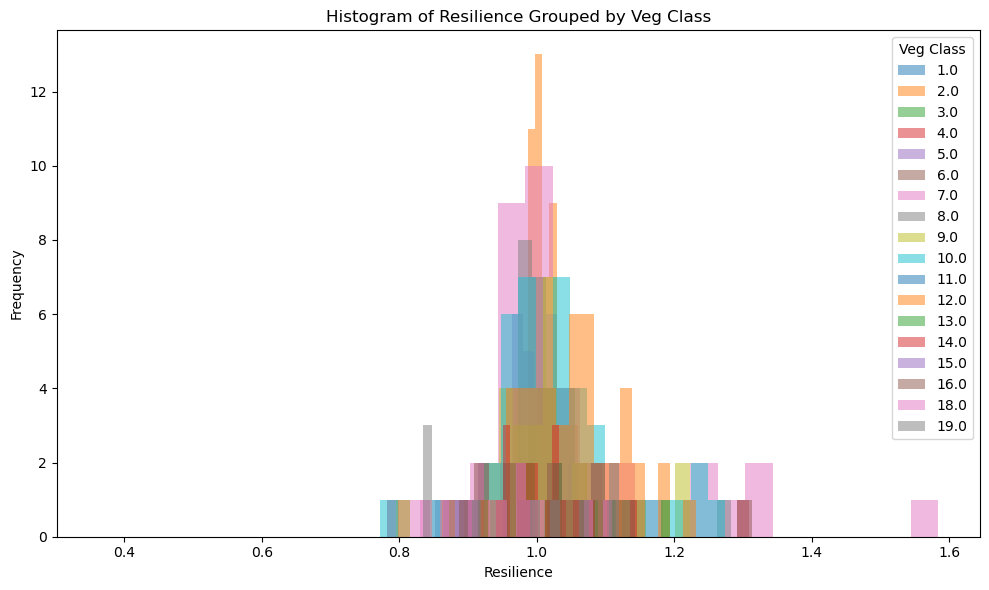

In [10]:
# Group by 'veg_class' level of the index
grouped = df_all.groupby(level='veg_class')['resilience']

# Plot histograms for each group
plt.figure(figsize=(10, 6))

for name, group in grouped:
    plt.hist(group.dropna(), bins=20, alpha=0.5, label=str(name))  # dropna for clean histogram

plt.xlabel('Resilience')
plt.ylabel('Frequency')
plt.title('Histogram of Resilience Grouped by Veg Class')
plt.legend(title='Veg Class')
plt.tight_layout()
plt.show()

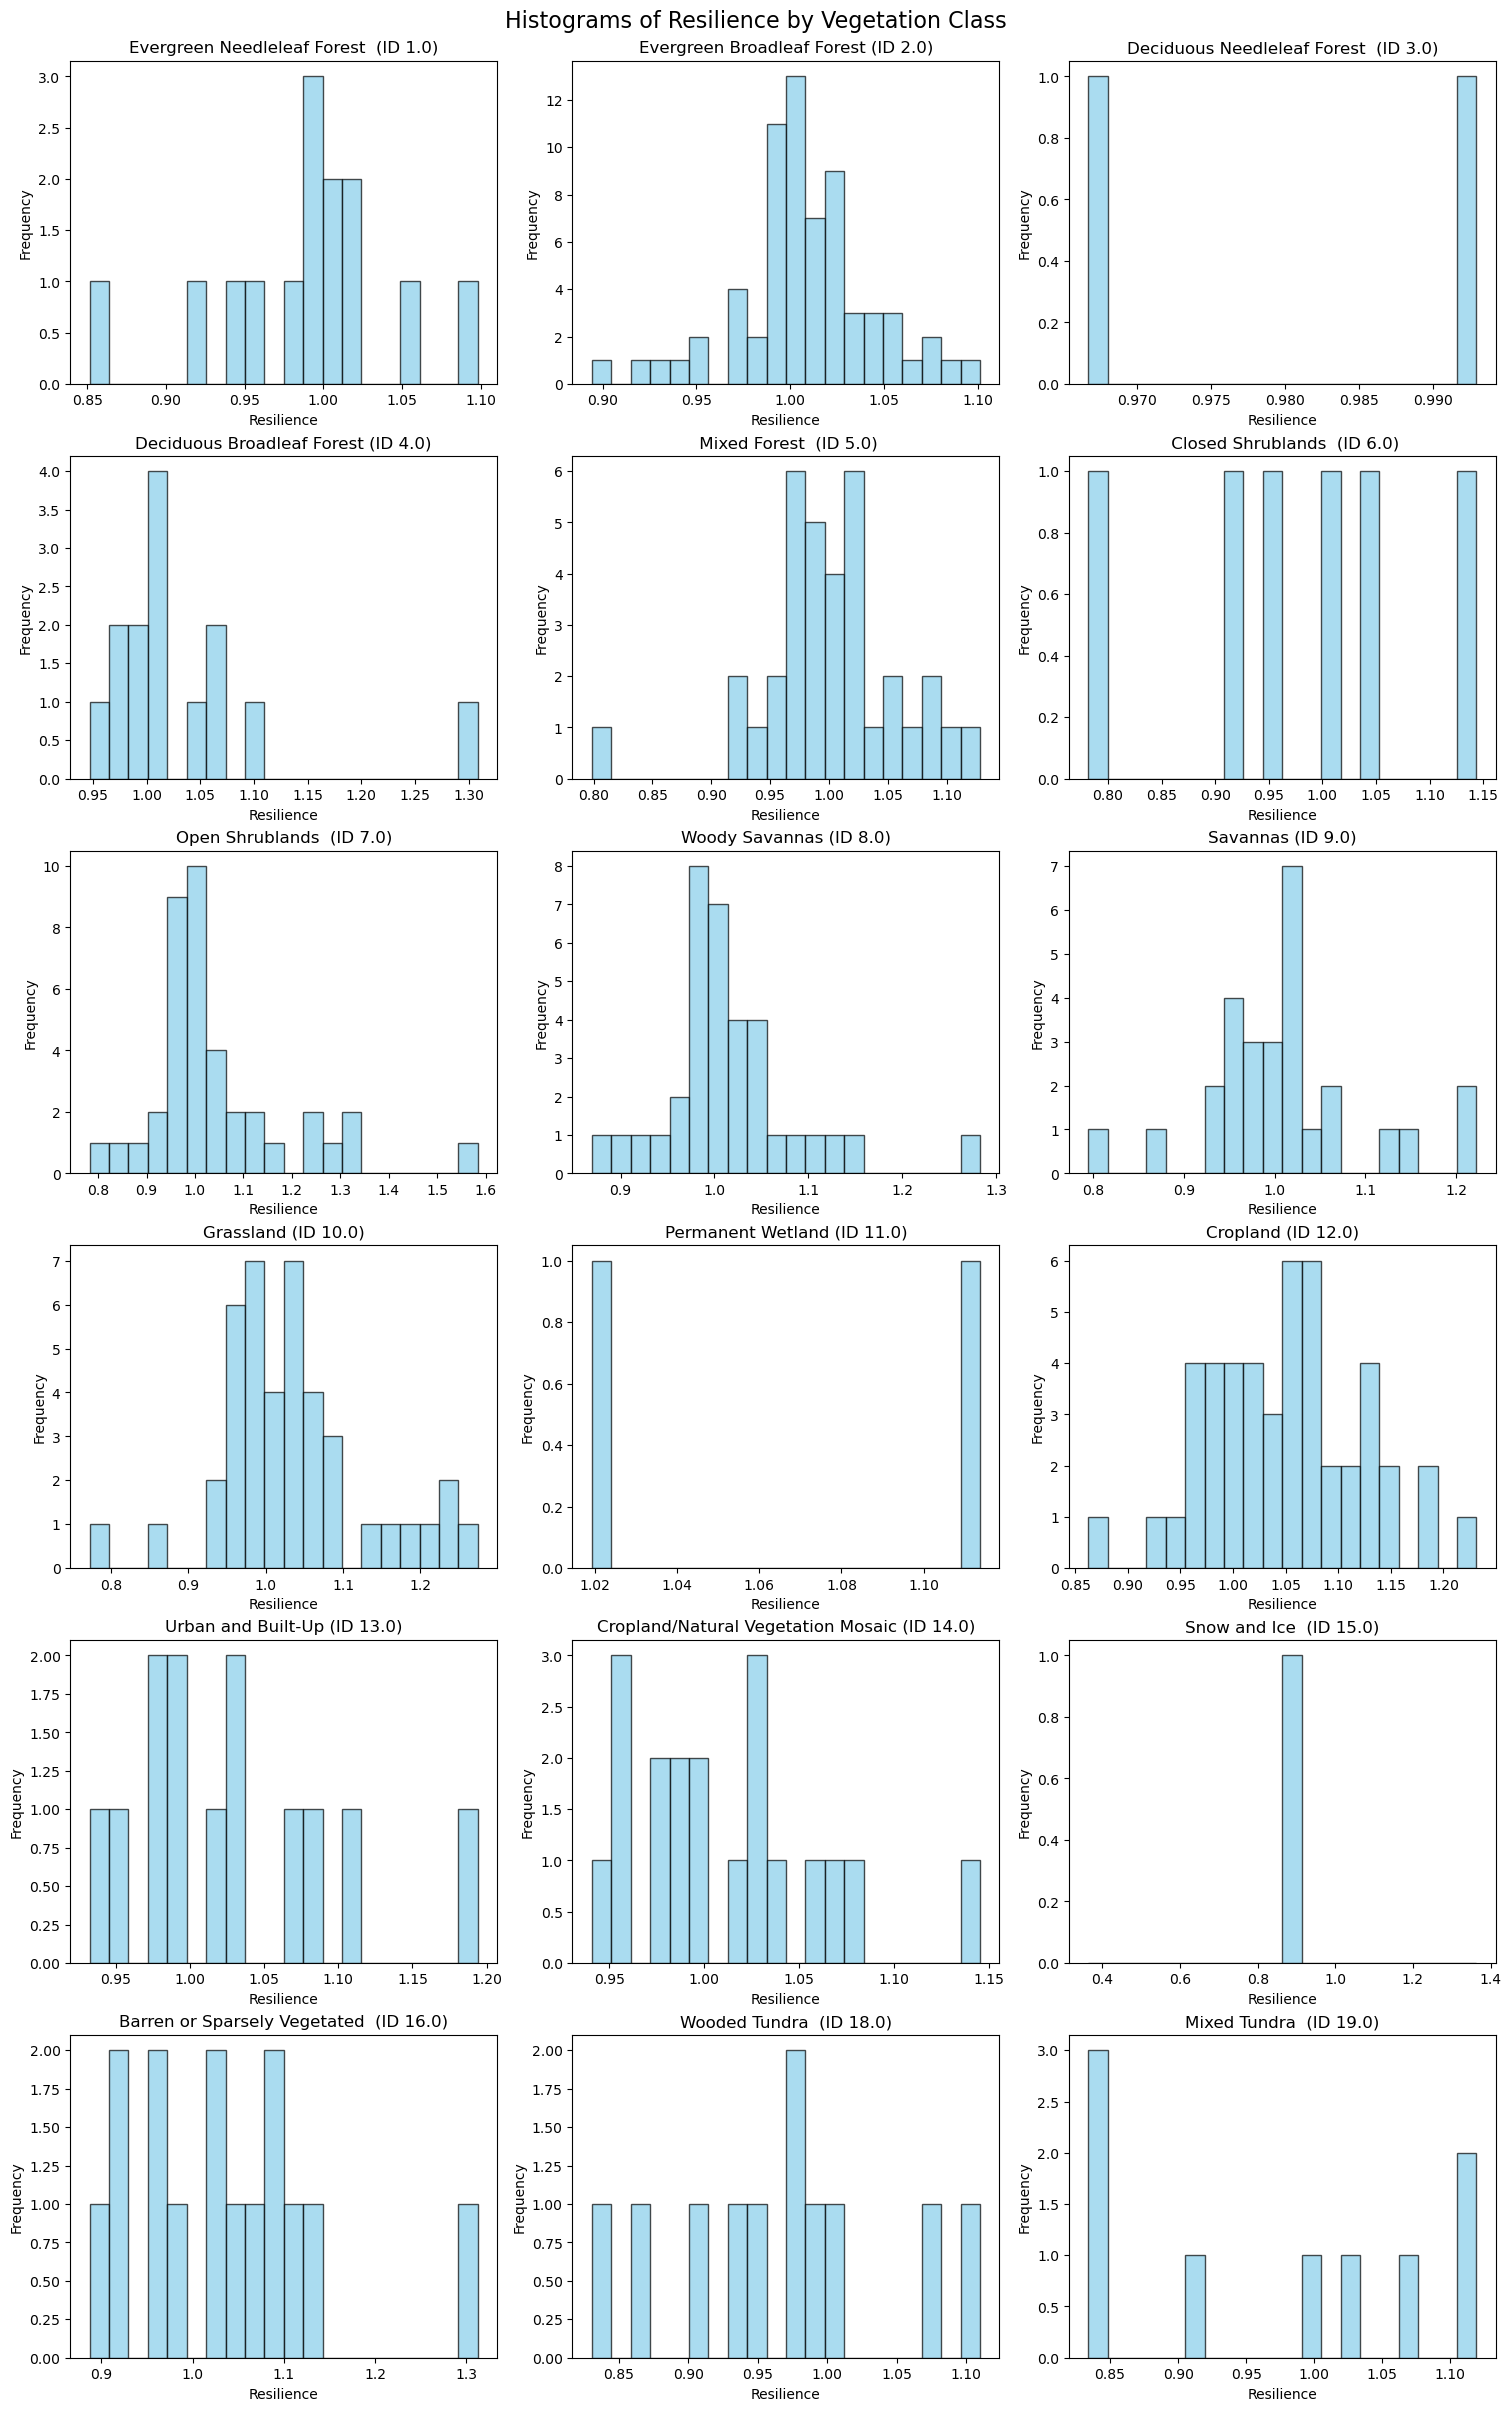

In [13]:
# Get mapping from numeric class to class name
class_name_map = df_translation.iloc[:, 0].to_dict()

# Group df_all by 'veg_class' level in MultiIndex
grouped = df_all.groupby(level='veg_class')['resilience']

# Get unique veg_classes and count for subplot grid
veg_classes = list(grouped.groups.keys())
n = len(veg_classes)

# Set up subplot grid (e.g., 3 columns)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Plot each veg_class in its own subplot with translated label
for i, veg_class in enumerate(veg_classes):
    class_name = class_name_map.get(veg_class, f'Class {veg_class}')  # fallback if not found
    group = grouped.get_group(veg_class)
    
    ax = axes[i]
    ax.hist(group.dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{class_name} (ID {veg_class})')
    ax.set_xlabel('Resilience')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Resilience by Vegetation Class', fontsize=16)
plt.show()

### Resistance

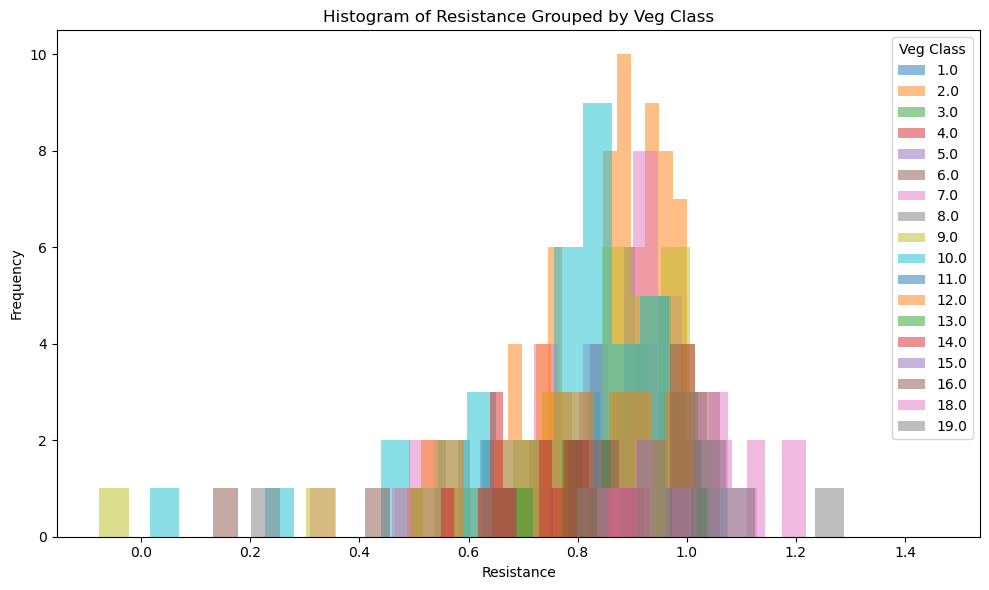

In [14]:
# Group by 'veg_class' level of the index
grouped = df_all.groupby(level='veg_class')['resistance']

# Plot histograms for each group
plt.figure(figsize=(10, 6))

for name, group in grouped:
    plt.hist(group.dropna(), bins=20, alpha=0.5, label=str(name))  # dropna for clean histogram

plt.xlabel('Resistance')
plt.ylabel('Frequency')
plt.title('Histogram of Resistance Grouped by Veg Class')
plt.legend(title='Veg Class')
plt.tight_layout()
plt.show()

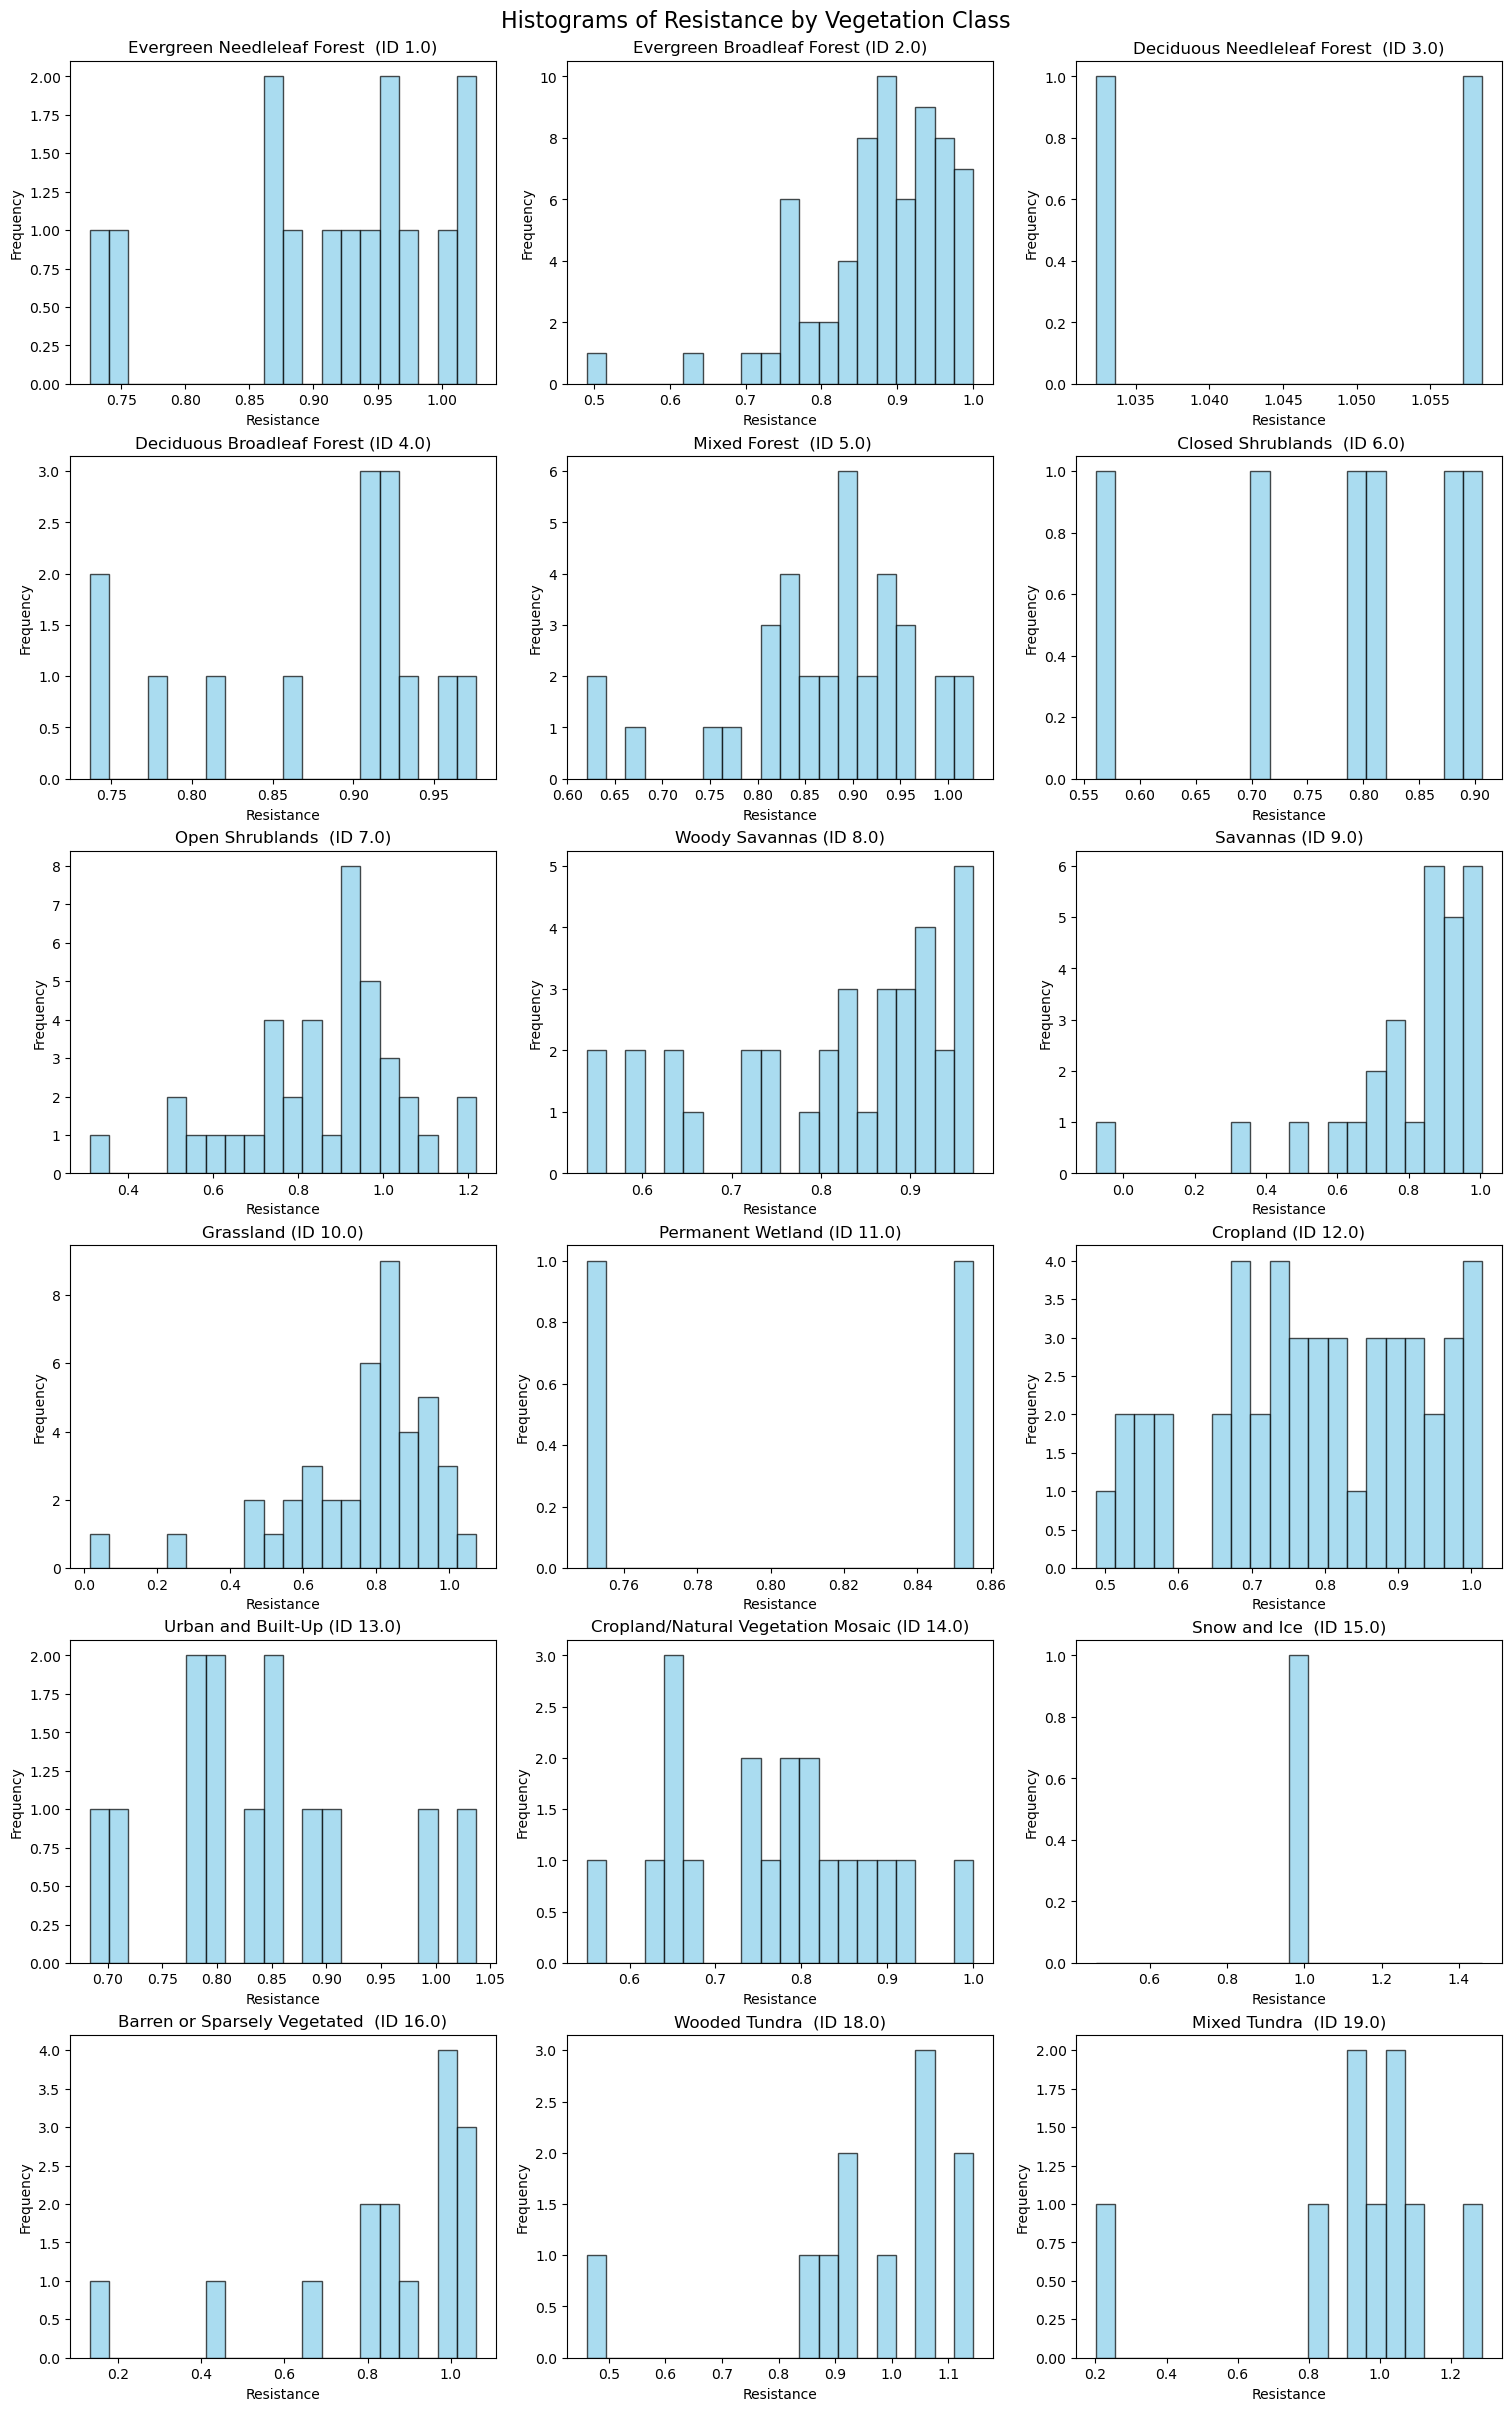

In [15]:
# Get mapping from numeric class to class name
class_name_map = df_translation.iloc[:, 0].to_dict()

# Group df_all by 'veg_class' level in MultiIndex
grouped = df_all.groupby(level='veg_class')['resistance']

# Get unique veg_classes and count for subplot grid
veg_classes = list(grouped.groups.keys())
n = len(veg_classes)

# Set up subplot grid (e.g., 3 columns)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Plot each veg_class in its own subplot with translated label
for i, veg_class in enumerate(veg_classes):
    class_name = class_name_map.get(veg_class, f'Class {veg_class}')  # fallback if not found
    group = grouped.get_group(veg_class)
    
    ax = axes[i]
    ax.hist(group.dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{class_name} (ID {veg_class})')
    ax.set_xlabel('Resistance')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Resistance by Vegetation Class', fontsize=16)
plt.show()

### Recovery

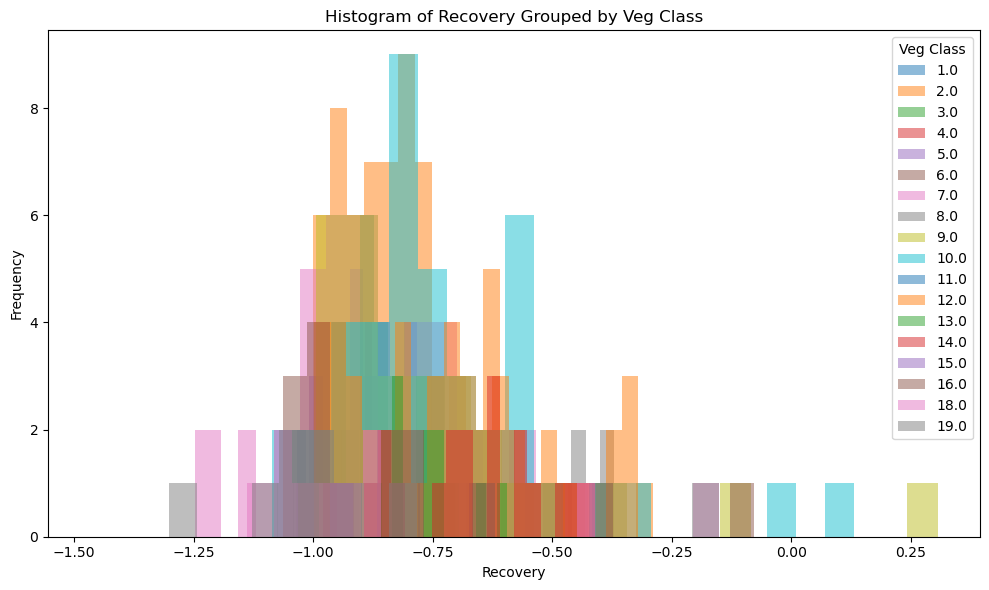

In [16]:
# Group by 'veg_class' level of the index
grouped = df_all.groupby(level='veg_class')['recovery']

# Plot histograms for each group
plt.figure(figsize=(10, 6))

for name, group in grouped:
    plt.hist(group.dropna(), bins=20, alpha=0.5, label=str(name))  # dropna for clean histogram

plt.xlabel('Recovery')
plt.ylabel('Frequency')
plt.title('Histogram of Recovery Grouped by Veg Class')
plt.legend(title='Veg Class')
plt.tight_layout()
plt.show()

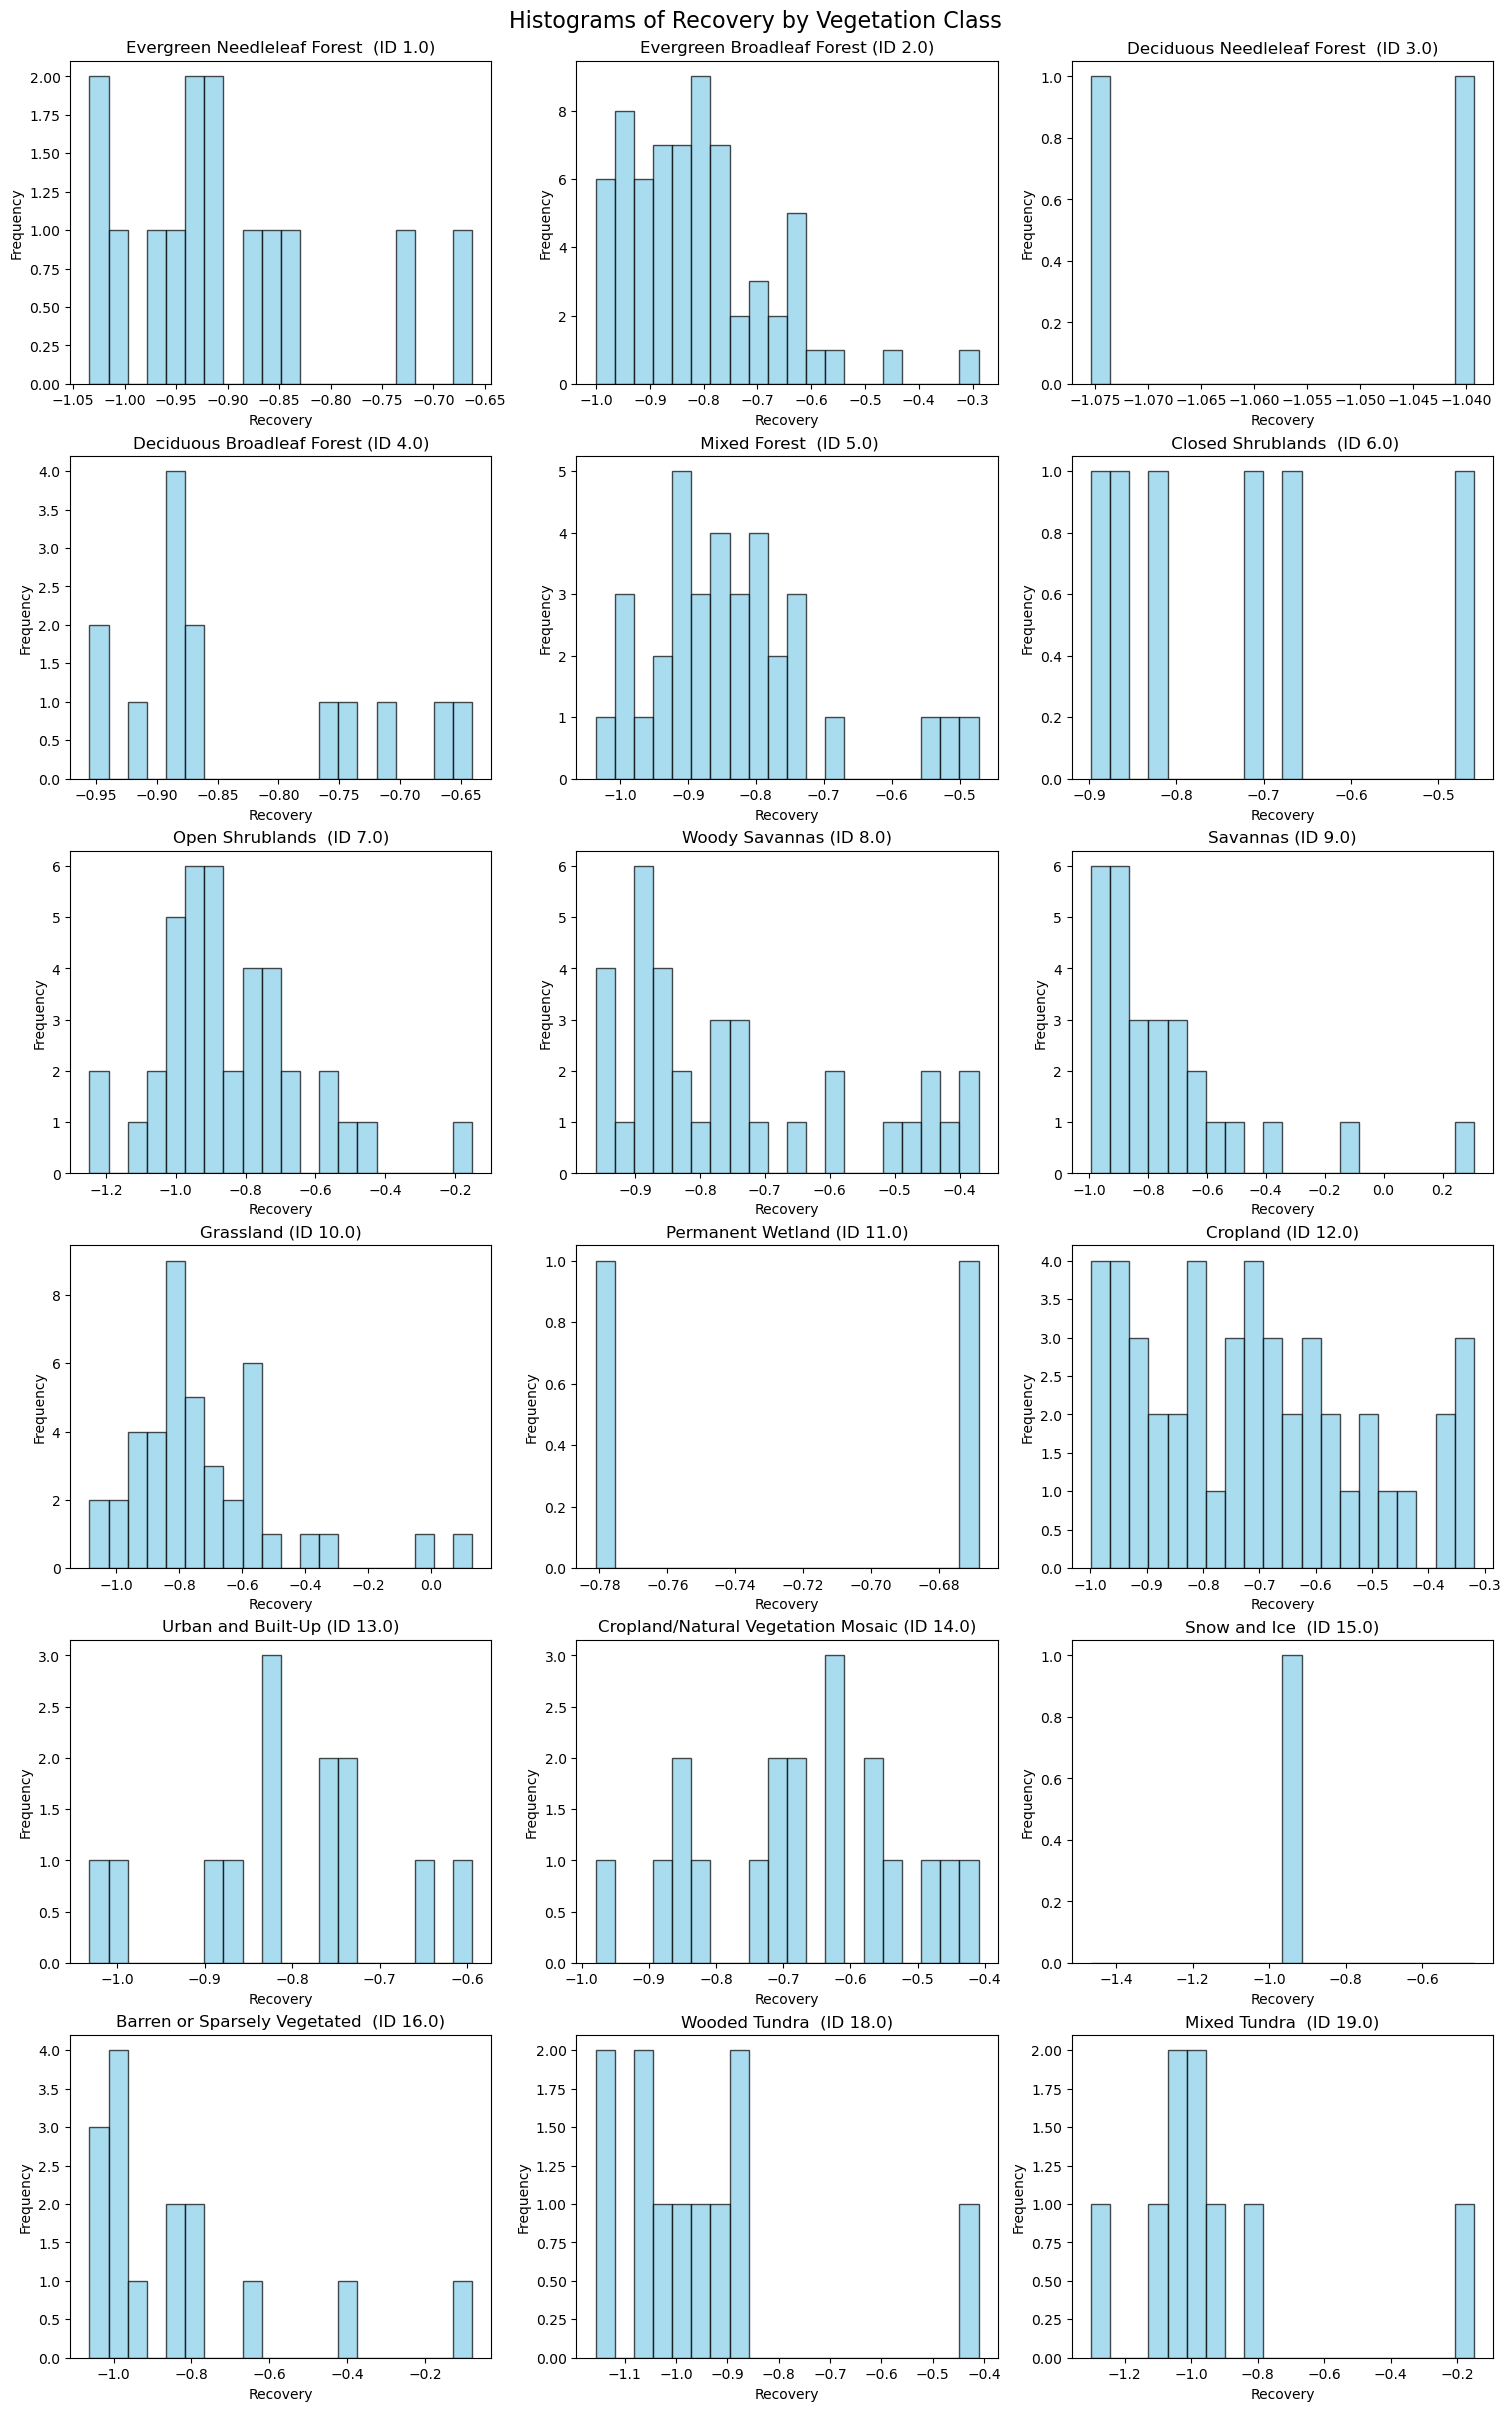

In [17]:
# Get mapping from numeric class to class name
class_name_map = df_translation.iloc[:, 0].to_dict()

# Group df_all by 'veg_class' level in MultiIndex
grouped = df_all.groupby(level='veg_class')['recovery']

# Get unique veg_classes and count for subplot grid
veg_classes = list(grouped.groups.keys())
n = len(veg_classes)

# Set up subplot grid (e.g., 3 columns)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Plot each veg_class in its own subplot with translated label
for i, veg_class in enumerate(veg_classes):
    class_name = class_name_map.get(veg_class, f'Class {veg_class}')  # fallback if not found
    group = grouped.get_group(veg_class)
    
    ax = axes[i]
    ax.hist(group.dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{class_name} (ID {veg_class})')
    ax.set_xlabel('Recovery')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Recovery by Vegetation Class', fontsize=16)
plt.show()